In [1]:
from pyNOMIC import combine, chop_correction, subtract_background, frame_registration, frame_evaluation, frame_rejection, frame_binning
import shutil, pathlib
import numpy as np

raw_dir = r"C:\Users\mmc\Music\Project\Vega\raw"
master_badmap_dir = r"C:\Users\mmc\Music\Project\master_badmap.fits"
obj='vega'

uncorrected_files, chops, frame_medians, para_angles, highpass_dir = combine(obj, raw_dir, master_badmap_dir, 0, "left", testing=True,\
                                                           test_number=1000, start_frame=30000)
files, chops, para_angles = chop_correction(uncorrected_files, highpass_dir, chops, para_angles)
subtracted_dir = subtract_background(files, raw_dir)
shutil.rmtree(highpass_dir)
psfmaxima, background_dev, reffit, array_shape, file_size, aligned_files = frame_registration(files, subtracted_dir)
shutil.rmtree(subtracted_dir)
np.savez(obj+"_NOMIC_reduced.npz", aligned_files, chops, para_angles, array_shape,\
         file_size, psfmaxima, background_dev, reffit)
print("Files saved")


'\nuncorrected_files, chops, frame_medians, para_angles, highpass_dir = combine(obj, raw_dir, master_badmap_dir, 0, "left", testing=True,                                                           test_number=1000, start_frame=30000)\nfiles, chops, para_angles = chop_correction(uncorrected_files, highpass_dir, chops, para_angles)\nsubtracted_dir = subtract_background(files, raw_dir)\nshutil.rmtree(highpass_dir)\npsfmaxima, background_dev, reffit, array_shape, file_size, aligned_files = frame_registration(files, subtracted_dir)\nshutil.rmtree(subtracted_dir)\nnp.savez(obj+"_NOMIC_reduced.npz", aligned_files, chops, para_angles, array_shape,         file_size, psfmaxima, background_dev, reffit)\nprint("Files saved")\n'

In [2]:
reduced_data = np.load(obj+"_NOMIC_reduced.npz", allow_pickle=True)
aligned_files = reduced_data["arr_0"]
chops = reduced_data["arr_1"]
para_angles = reduced_data["arr_2"]
array_shape = reduced_data["arr_3"]
file_size = reduced_data["arr_4"]
reffit = reduced_data["arr_7"]

fwhms, eccentricities, psfmaxima, background_dev, correlations, amplitudes, gauss_offsets = frame_evaluation(aligned_files, chops, array_shape, file_size)
np.savez(obj+"_NOMIC_evaluated.npz", fwhms, eccentricities, psfmaxima, background_dev, correlations, amplitudes, gauss_offsets)

print("Files saved")

Files saved


In [3]:
evaluations = np.load(obj+"_NOMIC_evaluated.npz", allow_pickle=True)

fwhms = evaluations["arr_0"]
eccentricities = evaluations["arr_1"]
psfmaxima = evaluations["arr_2"]
background_dev = evaluations["arr_3"]
correlations = evaluations["arr_4"]
amplitudes = evaluations["arr_5"]
gauss_offsets = evaluations["arr_6"]

frame_bool = frame_rejection(psfmaxima, background_dev, fwhms, eccentricities, correlations, amplitudes, gauss_offsets)
binned_files, binned_chops, binned_angles = frame_binning(aligned_files, raw_dir, frame_bool, chops, para_angles, array_shape)

binned_fwhms, binned_eccs, binned_psfmax, binned_backdev, binned_corrs, binned_amps, binned_gauss_offsets = frame_evaluation(aligned_files, chops, array_shape, file_size)
np.savez(obj+"_NOMIC_binned_evaluated.npz", binned_fwhms, binned_eccs, binned_psfmax, binned_backdev, binned_corrs, binned_amps, binned_gauss_offsets)
print("Files saved")

Binning files...


0it [00:00, ?it/s]C:\Users\mmc\Music\Project\pyNOMIC.py:76: RuntimeWarning: Mean of empty slice
  binned_frame = np.nanmean(buf_3D, axis=0)
7it [00:00, 13.58it/s]
7it [00:00, 12.77it/s]

[WindowsPath('C:/Users/mmc/Music/Project/Vega/binned/binned_aligned_n_210227_086116.fits')
 WindowsPath('C:/Users/mmc/Music/Project/Vega/binned/binned_aligned_n_210227_086119.fits')
 WindowsPath('C:/Users/mmc/Music/Project/Vega/binned/binned_aligned_n_210227_086223.fits')
 WindowsPath('C:/Users/mmc/Music/Project/Vega/binned/binned_aligned_n_210227_086228.fits')
 WindowsPath('C:/Users/mmc/Music/Project/Vega/binned/binned_aligned_n_210227_086335.fits')
 WindowsPath('C:/Users/mmc/Music/Project/Vega/binned/binned_aligned_n_210227_086342.fits')
 WindowsPath('C:/Users/mmc/Music/Project/Vega/binned/binned_aligned_n_210227_086477.fits')
 WindowsPath('C:/Users/mmc/Music/Project/Vega/binned/binned_aligned_n_210227_086486.fits')
 WindowsPath('C:/Users/mmc/Music/Project/Vega/binned/binned_aligned_n_210227_086597.fits')
 WindowsPath('C:/Users/mmc/Music/Project/Vega/binned/binned_aligned_n_210227_086608.fits')
 WindowsPath('C:/Users/mmc/Music/Project/Vega/binned/binned_aligned_n_210227_086711.fits')

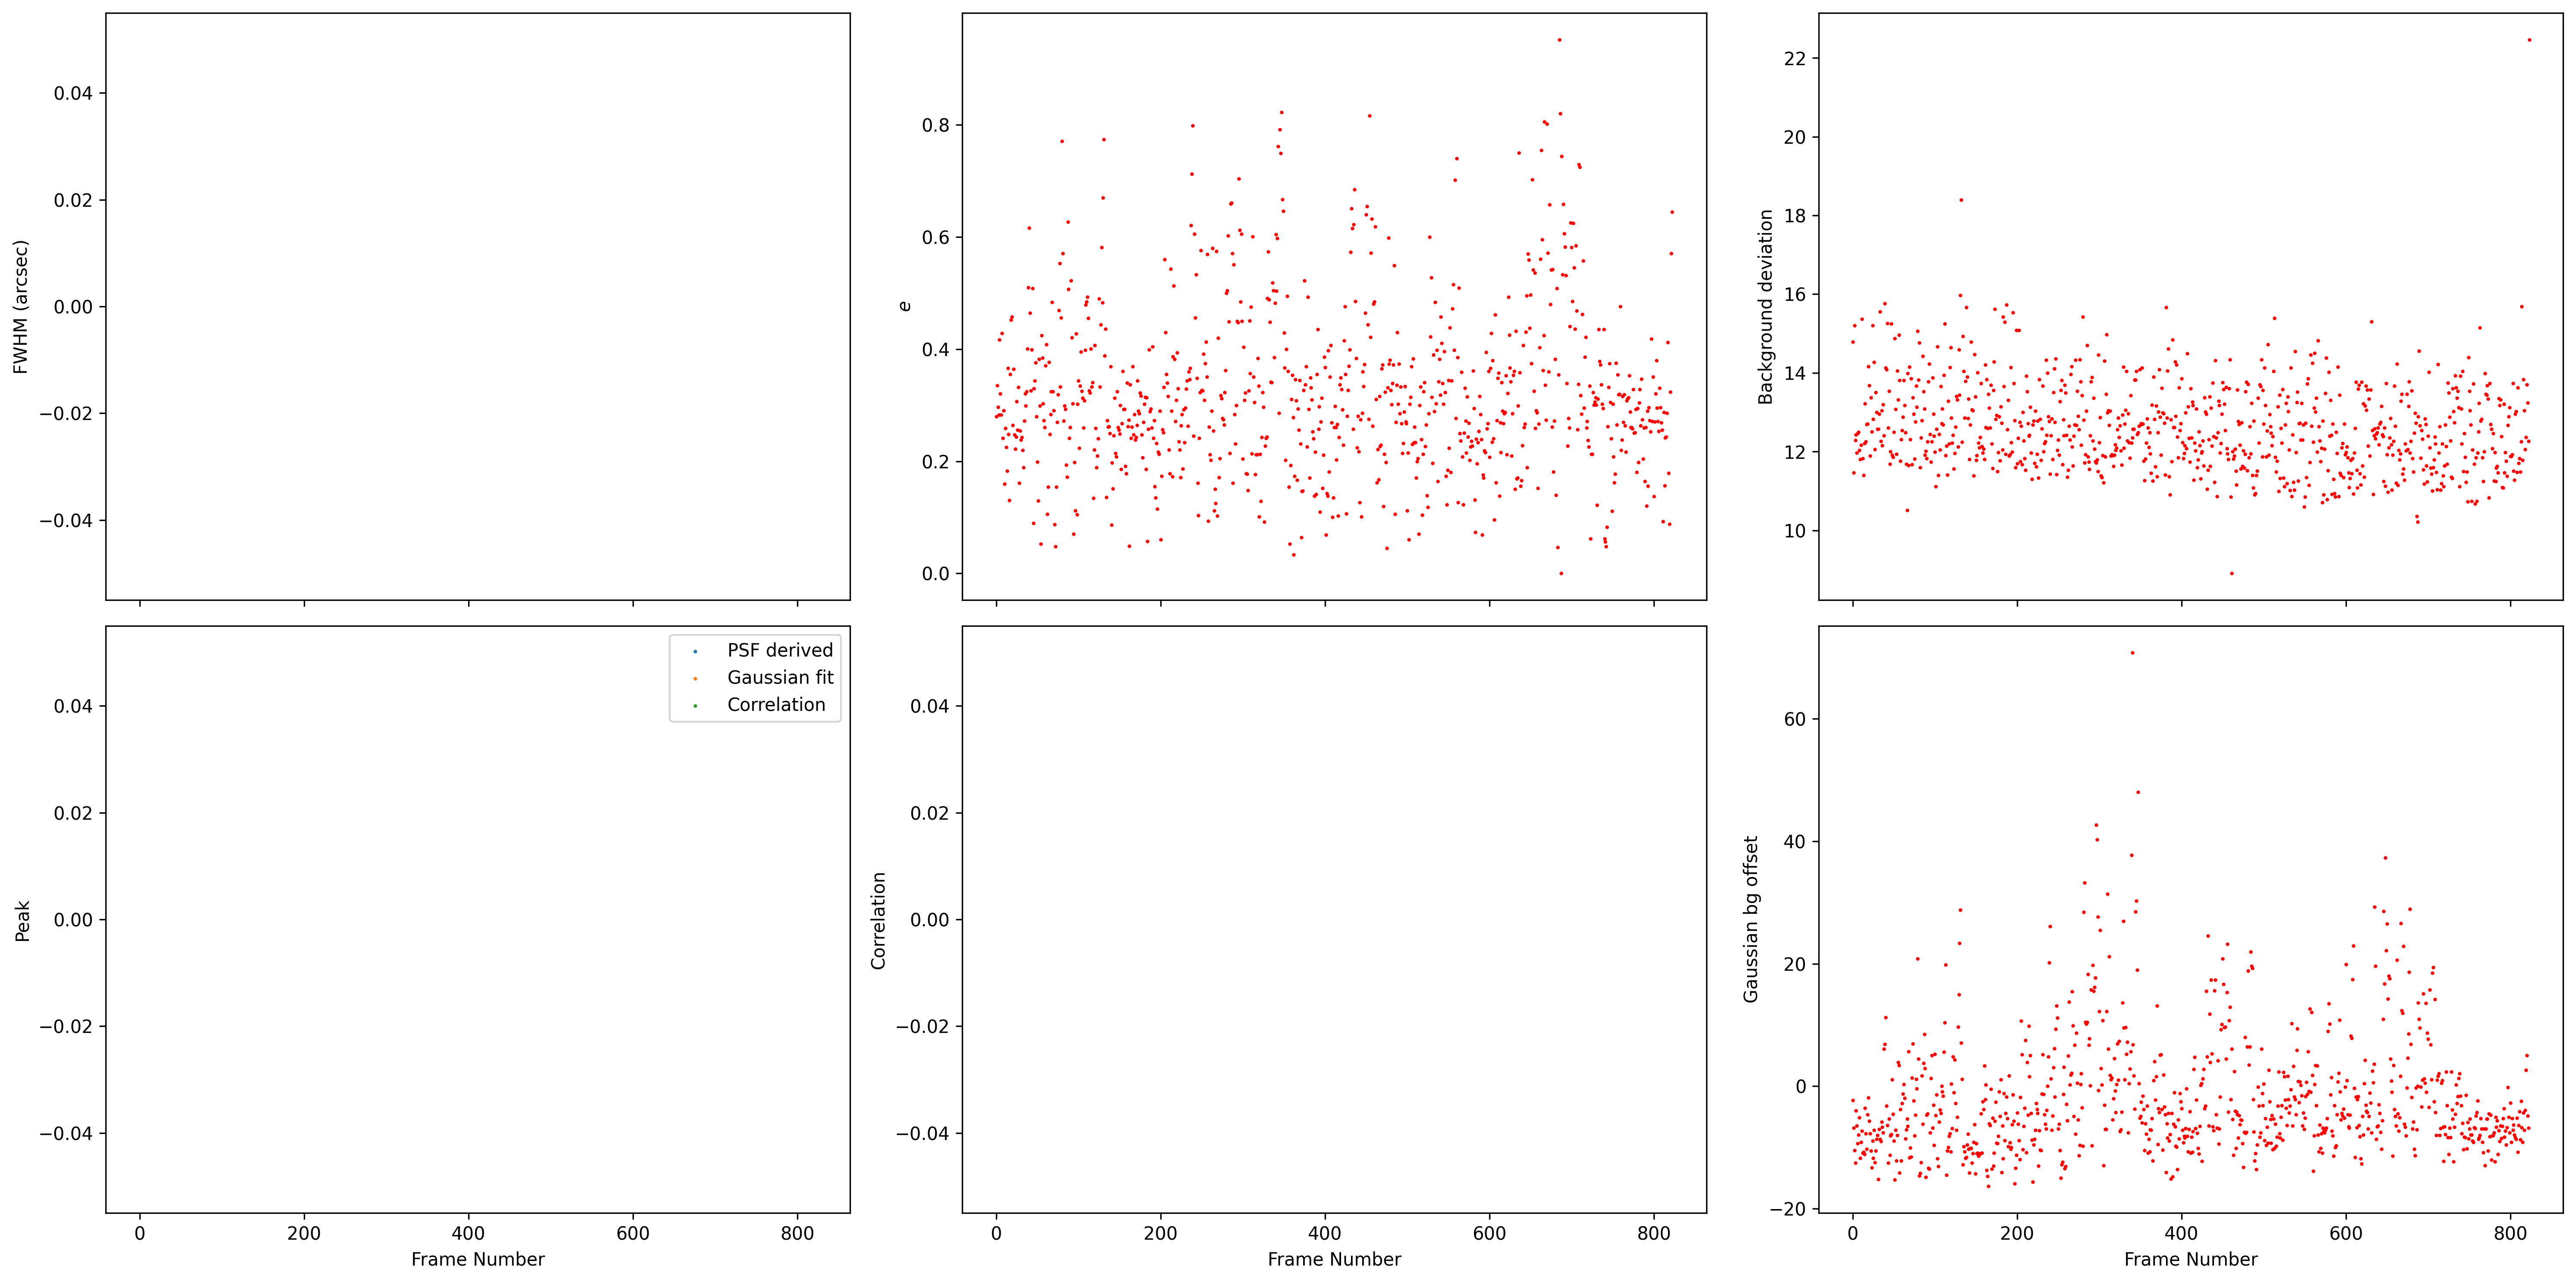

In [11]:
binned_evaluations = np.load(obj+"_NOMIC_binned_evaluated.npz", allow_pickle=True)

fwhms = binned_evaluations["arr_0"]
eccentricities = binned_evaluations["arr_1"]
psfmaxima = binned_evaluations["arr_2"]
background_dev = binned_evaluations["arr_3"]
correlations = binned_evaluations["arr_4"]
amplitudes = binned_evaluations["arr_5"]
gauss_offsets = binned_evaluations["arr_6"]

frame_bool = frame_rejection(psfmaxima, background_dev, fwhms, eccentricities, correlations, amplitudes, gauss_offsets)

import matplotlib.pyplot as plt
xlist = np.linspace(0, len(fwhms)-1, len(fwhms))
fig, ax = plt.subplots(2, 3,figsize=(20,10), dpi=300, sharex=True)

ax[0,0].scatter(xlist[frame_bool], fwhms[frame_bool], s=1)
ax[0,0].scatter(xlist[frame_bool ^ fwhms_bool], fwhms[frame_bool ^ fwhms_bool], s=1, color="red")
ax[0,0].set_ylabel("FWHM (arcsec)")
ax[0,1].scatter(xlist[frame_bool], eccentricities[frame_bool], s=1)
ax[0,1].scatter(xlist[~frame_bool], eccentricities[~frame_bool], s=1, color="red")
ax[0,1].set_ylabel(r"$e$")
ax[0,2].scatter(xlist[frame_bool], background_dev[frame_bool], s=1)
ax[0,2].scatter(xlist[~frame_bool], background_dev[~frame_bool], s=1, color="red")
ax[0,2].set_ylabel("Background deviation")

ax[1,0].scatter(xlist[frame_bool], psfmaxima[frame_bool], s=1,label="PSF derived")
ax[1,0].set_ylabel("Peak")
ax[1,0].scatter(xlist[frame_bool], amplitudes[frame_bool], s=1, label="Gaussian fit")
ax[1,0].scatter(xlist[frame_bool], correlations[frame_bool], s=1, label="Correlation")
ax[1,0].scatter(xlist[frame_bool ^ fwhms_bool], correlations[frame_bool ^ fwhms_bool], s=10, color="red")
ax[1,0].legend(loc="best")
ax[1,0].set_xlabel("Frame Number")
ax[1,1].set_ylabel("Correlation")
ax[1,1].scatter(xlist[frame_bool], correlations[frame_bool], s=1)
ax[1,1].scatter(xlist[~frame_bool], correlations[~frame_bool], s=1, color="red")
ax[1,1].set_xlabel("Frame Number")
'''
ax[1,0].scatter(xlist[~frame_bool], psfmaxima[~frame_bool], s=10,label="PSF derived", marker="1", color="tab:blue")
ax[1,0].scatter(xlist[~frame_bool], amplitudes[~frame_bool], s=10, label="Gaussian fit",marker="1", color="tab:orange")
ax[1,0].scatter(xlist[~frame_bool], correlations[~frame_bool], s=10, label="Correlation",marker="1", color="tab:green")
'''
ax[1,2].scatter(xlist[frame_bool], gauss_offsets[frame_bool], s=1)
ax[1,2].scatter(xlist[~frame_bool], gauss_offsets[~frame_bool], s=1, color="red")
ax[1,2].set_ylabel("Gaussian bg offset")
ax[1,2].set_xlabel("Frame Number")

plt.tight_layout()
plt.show()